# Erste Verarbeitungsschritte mit den Cicero Briefen (Perseus XML)

Dieses Notebook zeigt dir die ersten Schritte von XML Dateien zu einem kleinen, reproduzierbaren Mini Dataset.

**Ordnerstruktur**
- Dieses Notebook liegt in einem Ordner.
- Darin gibt es einen Ordner `data/`.
- In `data/` liegen die Perseus XML Dateien.

Wenn du die Dateien anders ablegst, passe unten den Pfad an.


## Lernziele (Kurz)
- Du liest die XML Dateien programmatisch ein.
- Du extrahierst zentrale Informationstypen (Absender, Empfaenger, Datum, Korpus, Buch, Brief).
- Du strukturierst die Infos tabellarisch in `pandas`.
- Du machst erste einfache Statistiken und schaust dir Unsicherheiten an (fehlende Felder, mehrdeutige Angaben).


In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt

try:
    from lxml import etree
    LXML = True
except Exception:
    import xml.etree.ElementTree as etree
    LXML = False

pd.set_option('display.max_colwidth', 120)


In [2]:
def find_xml_files() -> List[Path]:
    """Sucht XML Dateien.

    Erwartet standardmaessig einen Ordner `data/` neben dem Notebook.
    Falls es den Ordner nicht gibt, wird im aktuellen Ordner gesucht.
    """
    here = Path('.').resolve()
    data_dir = here / 'data'
    if data_dir.exists() and data_dir.is_dir():
        files = sorted(data_dir.glob('*.xml'))
    else:
        files = sorted(here.glob('*.xml'))
    return files

xml_files = find_xml_files()
xml_files

[PosixPath('/home/phillip/Documents/uzh/teaching/ss-2026/cicero-digital/content/data/phi0474.phi056.perseus-lat1-ad-familiares.xml'),
 PosixPath('/home/phillip/Documents/uzh/teaching/ss-2026/cicero-digital/content/data/phi0474.phi057.perseus-lat1-ad-atticum.xml'),
 PosixPath('/home/phillip/Documents/uzh/teaching/ss-2026/cicero-digital/content/data/phi0474.phi058.perseus-lat1-ad-quintum.xml'),
 PosixPath('/home/phillip/Documents/uzh/teaching/ss-2026/cicero-digital/content/data/phi0474.phi059.perseus-lat1-ad-brutum.xml')]

Wenn die Liste leer ist, kontrolliere die Ordnerstruktur. Das Notebook erwartet `./data/*.xml`.


In [3]:
def corpus_label_from_filename(p: Path) -> str:
    name = p.name.lower()
    if 'ad-familiares' in name:
        return 'ad_familiares'
    if 'ad-atticum' in name:
        return 'ad_atticum'
    if 'ad-quintum' in name:
        return 'ad_quintum_fratrem'
    if 'ad-brutum' in name:
        return 'ad_m_brutum'
    return p.stem

[corpus_label_from_filename(p) for p in xml_files]

['ad_familiares', 'ad_atticum', 'ad_quintum_fratrem', 'ad_m_brutum']

## XML und TEI Namespaces

Perseus verwendet TEI XML. TEI hat oft einen Namespace (etwa `http://www.tei-c.org/ns/1.0`).
Das ist wichtig, weil man sonst Elemente wie `div`, `seg` oder `date` nicht findet.

Wir lösen das so:
- Wir lesen die Datei als XML.
- Wir verwenden XPath mit `local-name()` (robust, auch wenn der Namespace variiert).


In [4]:
def parse_xml(path: Path):
    if LXML:
        parser = etree.XMLParser(recover=True, huge_tree=True)
        return etree.parse(str(path), parser)
    # ElementTree hat kein vollwertiges recover, aber fuer viele TEI Dateien reicht es.
    return etree.parse(str(path))

doc = parse_xml(xml_files[0]) if xml_files else None
type(doc) if doc is not None else 'Keine Datei gefunden'

lxml.etree._ElementTree

In [5]:
def xpath(el, expr: str):
    """Hilfsfunktion fuer XPath.
    In ElementTree gibt es kein vollwertiges XPath. Deshalb verwenden wir lxml, wenn vorhanden.
    """
    if not LXML:
        raise RuntimeError('Dieses Notebook braucht lxml für die XPath Abfragen. Installiere lxml oder verwende eine Umgebung, die es hat.')
    return el.xpath(expr)

if not LXML:
    print('Warnung: lxml ist nicht verfügbar. Installiere lxml, sonst funktioniert die Extraktion nicht.')


## Extraktion: Briefe als Einheiten

Im Perseus TEI sind Briefe typischerweise so organisiert:
- Ein `div` für das Werk.
- Darin ein `div` für das Buch (subtype `Book`).
- Darin `div` Elemente für einzelne Briefe (subtype `letter`).

Wir extrahieren pro Brief:
- Korpus (aus Dateiname)
- Buchnummer und Briefnummer (aus `n` Attributen)
- Datumszeile (seg rend `dateline`), sofern vorhanden
- Datum (date when), sofern vorhanden
- Anrede (seg rend `salute`) für Absender und Empfänger, sofern vorhanden
- Rohtext als einfache, whitespace normalisierte Textkette


In [27]:
def norm_ws(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()

def first_text(node_list) -> Optional[str]:
    if not node_list:
        return None
    if isinstance(node_list[0], str):
        return norm_ws(node_list[0])
    return norm_ws(' '.join(node_list[0].itertext()))

def get_attr(el, name: str) -> Optional[str]:
    v = el.get(name)
    return v if v is not None else None

def extract_sender_recipient_from_salute(salute: Optional[str]) -> Tuple[Optional[str], Optional[str]]:
    """Heuristik fuer Anreden wie:
    - 'Cicero Bruto salutem' -> ('Cicero', 'Bruto')
    - 'M. Cicero S.D. P. Lentulo procos.' -> ('M. Cicero', 'P. Lentulo procos')

    Idee:
    - Entfernt Schlussformeln wie 'salutem'.
    - Erkennt Marker wie 'S.D.' / 'SD' / 'S. D.' als Trenner.
    - Alles vor S.D. = Absender, alles danach = Empfaenger.
    - Bereinigt ueberfluessige Anfuehrungszeichen und Randzeichen.
    """

    if not salute:
        return None, None

    s = norm_ws(salute)

    # Ueberfluessige Anfuehrungszeichen entfernen
    s = s.replace('"', '').replace("'", "")

    # Schlussformel am Ende entfernen
    s = re.sub(r'\b(salutem)\b\.?\s*$', '', s, flags=re.IGNORECASE).strip()

    # Trenner fuer salutem dicit
    sd_pattern = re.compile(r'\bS\s*\.?\s*D\s*\.?\b', flags=re.IGNORECASE)
    m = sd_pattern.search(s)
    if m:
        sender = norm_ws(s[:m.start()])
        recipient = norm_ws(s[m.end():])

        # Fuehrende und abschliessende Satzzeichen entfernen
        recipient = re.sub(r'^[\s\.,;:]+', '', recipient)
        recipient = re.sub(r'[\s\.,;:]+$', '', recipient)

        sender = sender if sender else None
        recipient = recipient if recipient else None
        return sender, recipient

    # Fallback
    parts = s.split()
    if len(parts) < 2:
        return None, None

    sender = parts[0]
    recipient = parts[1]

    return sender, recipient

def extract_letters_from_doc(doc, corpus: str):
    root = doc.getroot()
    letter_divs = xpath(root, "//*[local-name()='div' and @subtype='letter']")
    out = []
    for ld in letter_divs:
        book_div = xpath(ld, "ancestor::*[local-name()='div' and @subtype='Book'][1]")
        book_n = get_attr(book_div[0], 'n') if book_div else None
        letter_n = get_attr(ld, 'n')

        dateline = first_text(xpath(ld, ".//*[local-name()='seg' and @rend='dateline']"))
        salute = first_text(xpath(ld, ".//*[local-name()='seg' and @rend='salute']"))
        date_el = xpath(ld, ".//*[local-name()='date'][1]")
        date_when = get_attr(date_el[0], 'when') if date_el else None

        sender, recipient = extract_sender_recipient_from_salute(salute)

        text = norm_ws(' '.join(ld.itertext()))
        stable_id = f"{corpus}:{book_n}.{letter_n}" if book_n and letter_n else None

        out.append({
            'id': stable_id,
            'corpus': corpus,
            'book_n': book_n,
            'letter_n': letter_n,
            'dateline': dateline,
            'date_when': date_when,
            'salute': salute,
            'sender': sender,
            'recipient': recipient,
            'text_raw': text,
        })
    return out


In [39]:
all_rows = []
for p in xml_files:
    corpus = corpus_label_from_filename(p)
    doc = parse_xml(p)
    all_rows.extend(extract_letters_from_doc(doc, corpus))

len(all_rows), list(all_rows[0].keys()) if all_rows else ('Keine Briefe extrahiert', [])

(930,
 ['id',
  'corpus',
  'book_n',
  'letter_n',
  'dateline',
  'date_when',
  'salute',
  'sender',
  'recipient',
  'text_raw'])

In [40]:
df = pd.DataFrame(all_rows)
df.head(10)

,id,corpus,book_n,letter_n,dateline,date_when,salute,sender,recipient,text_raw
0,ad_familiares:1.1,ad_familiares,1,1,Scr. Romae Id. Ian. a. u. c. 698 (a. Chr. 56) .,-0056,None,None,None,Scr. Romae Id. Ian. a. u. c. 698 (a. Chr. 56) . M. CICERO S. D. P. LENTVLO PROCOS. ego omni officio ac potius pietat...
1,ad_familiares:1.2,ad_familiares,1,2,Scr. Romae a. d. xvi Kal. Febr. a. 698 (56).,None,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,Scr. Romae a. d. xvi Kal. Febr. a. 698 (56). M. CICERO S.D. P. LENTVLO PROCOS. Idibus Ianuariis in senatu nihil est ...
2,ad_familiares:1.3,ad_familiares,1,3,Scr. Romae medio mense Ian. a. 698 (56) .,-0056,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,"Scr. Romae medio mense Ian. a. 698 (56) . M. CICERO S.D. P. LENTVLO PROCOS. A. Trebonio, qui in tua provincia magna ..."
3,ad_familiares:1.4,ad_familiares,1,4,Scr. Romae circiter xv Kal. Febr. a. 698 (56).,None,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,Scr. Romae circiter xv Kal. Febr. a. 698 (56). M. CICERO S.D. P. LENTVLO PROCOS. A. d. xvi K. Febr. cum in senatu pu...
4,ad_familiares:1.5a,ad_familiares,1,5a,Scr. Romae circiter Non. Febr. a. 698 (56) .,-0056,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,Scr. Romae circiter Non. Febr. a. 698 (56) . M. CICERO S.D. P. LENTVLO PROCOS. tametsi mihi nihil fuit optatius quam...
5,ad_familiares:1.5b,ad_familiares,1,5b,Scr. Romae paulo post vi Id. Febr. a. 698 (56).,None,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,Scr. Romae paulo post vi Id. Febr. a. 698 (56). M. CICERO S.D. P. LENTVLO PROCOS. hic quae agantur quaeque acta sint...
6,ad_familiares:1.6,ad_familiares,1,6,"Scr. Romae mense ut videtur, Mart. a. 698 (56) .",-0056,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,"Scr. Romae mense ut videtur, Mart. a. 698 (56) . M. CICERO S.D. P. LENTVLO PROCOS. quae gerantur, accipies ex Pollio..."
7,ad_familiares:1.7,ad_familiares,1,7,Scr. Romae exeunte mense Quint. a. 698 (56) .,-0056,M. CICERO S.D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,"Scr. Romae exeunte mense Quint. a. 698 (56) . M. CICERO S.D. P. LENTVLO PROCOS. legi tuas litteras, quibus ad me scr..."
8,ad_familiares:1.8,ad_familiares,1,8,Scr. Romae mense Ian. a. 699 (55) .,-0055,M. CICERO S. D. P. LENTVLO PROCOS.,M. CICERO,P. LENTVLO PROCOS,"Scr. Romae mense Ian. a. 699 (55) . M. CICERO S. D. P. LENTVLO PROCOS. de omnibus rebus, quae ad te pertinent, quid ..."
9,ad_familiares:1.9,ad_familiares,1,9,Scr. Romae mense Dec. a. 700 (54) .,-0054,M. CICERO S. D. LENTVLO IMP.,M. CICERO,LENTVLO IMP,"Scr. Romae mense Dec. a. 700 (54) . M. CICERO S. D. LENTVLO IMP. periucundae mihi fuerunt litterae tuae, quibus inte..."


In [42]:
df.tail(10)

,id,corpus,book_n,letter_n,dateline,date_when,salute,sender,recipient,text_raw
920,ad_m_brutum:1.14,ad_m_brutum,1,14,"Scr. Romae v Id. Quint. , a. 711 (43).",None,Cicero Bruto salutem,Cicero,Bruto,"Scr. Romae v Id. Quint. , a. 711 (43). Cicero Bruto salutem breves litterae tuae—breves dico, immo nullae. tribusne ..."
921,ad_m_brutum:1.15,ad_m_brutum,1,15,Scr. Romae circ. med. in. Quint. a. 711 (43),-0043,Cicero Bruto salutem,Cicero,Bruto,Scr. Romae circ. med. in. Quint. a. 711 (43) Cicero Bruto salutem Messalam habes. quibus igitur litteris tam accurat...
922,ad_m_brutum:1.16,ad_m_brutum,1,16,Scr. Athenis in. Maio a. 711 (a).,None,Brutus Ciceroni salutem,Brutus,Ciceroni,"Scr. Athenis in. Maio a. 711 (a). Brutus Ciceroni salutem particulam litterularum tuarum, quas misisti Octavio, legi..."
923,ad_m_brutum:1.17,ad_m_brutum,1,17,"Scr. m. Maio, ut videtur, a. 711 (43) .",-0043,Brutus Attico salutem,Brutus,Attico,"Scr. m. Maio, ut videtur, a. 711 (43) . Brutus Attico salutem scribis mihi mirari Ciceronem quod nihil significem um..."
924,ad_m_brutum:1.18,ad_m_brutum,1,18,"Scr. Romae vi K. Sex. , a. 711 (43).",None,Cicero Bruto salutem,Cicero,Bruto,"Scr. Romae vi K. Sex. , a. 711 (43). Cicero Bruto salutem Cum saepe te litteris hortatus essem ut quam primum rei pu..."
925,ad_m_brutum:2.1,ad_m_brutum,2,1,Scr. Romae ex. m. Mart. ant in. Apr. a. 711 (43) .,-0043,Cicero Bruto salutem,Cicero,Bruto,"Scr. Romae ex. m. Mart. ant in. Apr. a. 711 (43) . Cicero Bruto salutem Cum haec scribebam, res existimabatur in ext..."
926,ad_m_brutum:2.2,ad_m_brutum,2,2,Scr. Romae iii Id. Apr. a. 711 (43).,None,Cicero Bruto salutem,Cicero,Bruto,"Scr. Romae iii Id. Apr. a. 711 (43). Cicero Bruto salutem Planci animum in rem publicam egregium, legiones, auxilia,..."
927,ad_m_brutum:2.3,ad_m_brutum,2,3,Scr. Dyrrach i K. Apr. a. 711 (43).,None,Brutus Ciceroni salutem,Brutus,Ciceroni,"Scr. Dyrrach i K. Apr. a. 711 (43). Brutus Ciceroni salutem Litteras tuas valde exspecto, quas scripsisti post nunti..."
928,ad_m_brutum:2.4,ad_m_brutum,2,4,Scr. Romae prid. Id. Apr. mane a. 711 (43).,None,Cicero Bruto salutem,Cicero,Bruto,Scr. Romae prid. Id. Apr. mane a. 711 (43). Cicero Bruto salutem Datis mane a. d. in id . April. Scaptio litteris eo...
929,ad_m_brutum:2.5,ad_m_brutum,2,5,Scr. Romae xviii K. Mai. a. 711 (43).,None,Cicero Bruto salutem,Cicero,Bruto,Scr. Romae xviii K. Mai. a. 711 (43). Cicero Bruto salutem quae litterae tuo nomine recitatae sint id . April. in se...


In [41]:
df.describe()

,id,corpus,book_n,letter_n,dateline,date_when,salute,sender,recipient,text_raw
count,484,930,484,930,930,420,929,929,895,930
unique,484,4,16,134,857,23,296,86,165,930
top,ad_familiares:1.1,ad_atticum,13,1,"Scr. Romae, ut videtur, a. 708 (46) .",-0046,CICERO ATTICO salutem,CICERO,ATTICO,Scr. Romae Id. Ian. a. u. c. 698 (a. Chr. 56) . M. CICERO S. D. P. LENTVLO PROCOS. ego omni officio ac potius pietat...
freq,1,446,81,37,24,82,411,582,412,1


## Normalisierung: Datum

In TEI steht das Datum oft als `when="-0043"`. Wir extrahieren daraus ein Jahr (Integer), wenn moeglich.
Falls kein `when` vorhanden ist, bleibt das Feld leer.


In [36]:
def parse_year(date_when: Optional[str]) -> Optional[int]:
    if not date_when:
        return None
    m = re.match(r'^-?\d{1,4}$', date_when.strip())
    if not m:
        return None
    return int(date_when)

df['year'] = df['date_when'].apply(parse_year)
df[['date_when', 'year']].dropna().head(10)

,date_when,year
0,-0056,-56.0
2,-0056,-56.0
4,-0056,-56.0
6,-0056,-56.0
7,-0056,-56.0
8,-0055,-55.0
9,-0054,-54.0
10,-0054,-54.0
11,-0053,-53.0
12,-0053,-53.0


## Strukturierung in `pandas`

Jetzt haben wir eine Tabelle, die du sehr einfach filtern, gruppieren und exportieren kannst.

Wir erzeugen ein kleines Mini Dataset (CSV) und legen es in `outputs/` ab.


In [37]:
out_dir = Path('outputs')
out_dir.mkdir(exist_ok=True)

mini_cols = ['id','corpus','book_n','letter_n','sender','recipient','date_when','year','dateline']
mini = df[mini_cols].copy()
mini_path = out_dir / 'cicero_letters_metadata_mini.csv'
mini.to_csv(mini_path, index=False)
mini_path

PosixPath('outputs/cicero_letters_metadata_mini.csv')

## Erste Statistiken

Wir schauen uns an:
- Wie viele Briefe pro Korpus vorhanden sind.
- Wie viele Briefe ein Datum haben.
- Welche Absender und Empfaenger am häufigsten vorkommen (nur nach unserer einfachen Heuristik).


In [32]:
df.groupby('corpus').size().sort_values(ascending=False)

corpus
ad_atticum            446
ad_familiares         431
ad_quintum_fratrem     27
ad_m_brutum            26
dtype: int64

In [43]:
df['date_when'].notna().groupby(df['corpus']).mean().sort_values(ascending=False)

corpus
ad_quintum_fratrem    0.740741
ad_familiares         0.561485
ad_m_brutum           0.461538
ad_atticum            0.327354
Name: date_when, dtype: float64

In [44]:
df['sender'].value_counts(dropna=True).head(10)

sender
CICERO            582
M. CICERO          84
TVLLIVS            32
MARCVS             27
M.                 26
CAELIVS            17
Cicero             17
M. CICERO IMP.     15
PLANCVS            11
Brutus              9
Name: count, dtype: int64

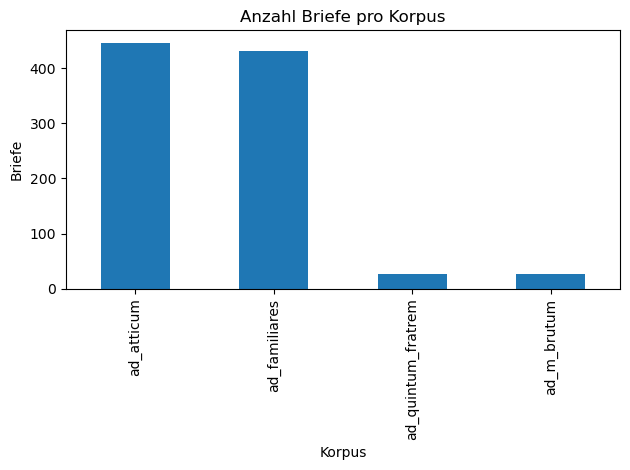

In [45]:
counts = df.groupby('corpus').size().sort_values(ascending=False)
plt.figure()
counts.plot(kind='bar')
plt.title('Anzahl Briefe pro Korpus')
plt.xlabel('Korpus')
plt.ylabel('Briefe')
plt.tight_layout()
plt.show()

## Qualitaet und Unsicherheit

Ein wichtiger Schritt ist die kritische Bewertung:
- Fehlen Datum oder Ort oft systematisch?
- Sind Absender und Empfänger immer eindeutig?
- Hängen spätere Visualisierungen stark an wenigen Feldern?

Hier ein schneller Blick auf fehlende Werte.


In [47]:
def parse_year(date_when):
    if not date_when:
        return None
    if re.match(r'^-?\d{1,4}$', str(date_when)):
        return int(date_when)
    return None

df['year'] = df['date_when'].apply(parse_year)

mini_cols = ['id','corpus','book_n','letter_n','sender','recipient','date_when','year','dateline']
df[mini_cols].isna().mean().sort_values(ascending=False)

date_when    0.548387
year         0.548387
id           0.479570
book_n       0.479570
recipient    0.037634
sender       0.001075
corpus       0.000000
letter_n     0.000000
dateline     0.000000
dtype: float64

## Ausblick

Als nächste Schritte bieten sich an:
- Orte aus der Datumszeile oder aus dem Text zu extrahieren.
- Brieftexte sauberer zu extrahieren (ohne Kopf und Metadaten), zum Beispiel nur `p` Abschnitte.
- Ein besseres Schema für Personen zu bauen, damit die Namen normalisiert werden.
